# REGRESSION TASK
The objective os this code is to train a machine learning algorithm in predicting the quality of the wine depending on its properties.

Step 1. Import Libraries and Load Dataset

In [ ]:
import pandas as pd
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_squared_error as mse, mean_absolute_error as mae)
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor

In [50]:
df = pd.read_csv('wine-dataset.csv')
# https://www.kaggle.com/datasets/debopamdey/combined-wine-dataset-red-and-white-wines

Step 2. Analyze and Clean Dataset

In [51]:
df.describe()

,volatile_acidity,density,free_sulfur_dioxide,fixed_acidity,pH,quality,alcohol,citric_acid,sulphates,total_sulfur_dioxide,residual_sugar,chlorides
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,0.339666,0.994697,30.525319,7.215307,3.218501,5.818378,10.491801,0.318633,0.531268,115.744574,5.443235,0.056034
std,0.164636,0.002999,17.749400,1.296434,0.160787,0.873255,1.192712,0.145318,0.148806,56.521855,4.757804,0.035034
min,0.080000,0.987110,1.000000,3.800000,2.720000,3.000000,8.000000,0.000000,0.220000,6.000000,0.600000,0.009000
25%,0.230000,0.992340,17.000000,6.400000,3.110000,5.000000,9.500000,0.250000,0.430000,77.000000,1.800000,0.038000
50%,0.290000,0.994890,29.000000,7.000000,3.210000,6.000000,10.300000,0.310000,0.510000,118.000000,3.000000,0.047000
75%,0.400000,0.996990,41.000000,7.700000,3.320000,6.000000,11.300000,0.390000,0.600000,156.000000,8.100000,0.065000
max,1.580000,1.038980,289.000000,15.900000,4.010000,9.000000,14.900000,1.660000,2.000000,440.000000,65.800000,0.611000


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   volatile_acidity      6497 non-null   float64
 1   density               6497 non-null   float64
 2   free_sulfur_dioxide   6497 non-null   float64
 3   fixed_acidity         6497 non-null   float64
 4   pH                    6497 non-null   float64
 5   quality               6497 non-null   float64
 6   alcohol               6497 non-null   float64
 7   citric_acid           6497 non-null   float64
 8   sulphates             6497 non-null   float64
 9   total_sulfur_dioxide  6497 non-null   float64
 10  residual_sugar        6497 non-null   float64
 11  chlorides             6497 non-null   float64
 12  wine_type             6497 non-null   str    
dtypes: float64(12), str(1)
memory usage: 660.0 KB


In [53]:
df.head()

,volatile_acidity,density,free_sulfur_dioxide,fixed_acidity,pH,quality,alcohol,citric_acid,sulphates,total_sulfur_dioxide,residual_sugar,chlorides,wine_type
0,0.420,0.99848,57.0,6.9,3.08,5.0,9.4,0.20,0.54,201.0,15.4,0.043,White
1,0.530,0.99489,29.0,6.5,3.38,6.0,10.3,0.06,0.83,44.0,2.0,0.063,Red
2,0.270,0.99790,50.0,6.8,3.03,6.0,8.6,0.28,0.38,163.0,13.3,0.076,White
3,0.160,0.99494,24.0,6.7,3.34,6.0,11.2,0.64,0.71,52.0,2.1,0.059,Red
4,0.545,0.99650,27.0,7.9,3.36,6.0,10.7,0.06,0.67,61.0,4.0,0.087,Red


There seems to be outliers in the following features: volatile_acidity, free_sulfur_dioxide, fixed_acidity, citric_acid, sulphates, total_sulfur_dioxide, residual_sugar and chlorides.  
There is high chance that these are not really outliers but actual differences in the wine composition (especially when considering the variable alcohol).  
Instead of removing outliers, I will focus on removing invalid/impossible data by manually analyzing the data.

In [54]:
summary = pd.DataFrame({
    "Feature": df.columns,
    "Min": df.min().values,
    "Max": df.max().values
})
summary

,Feature,Min,Max
0,volatile_acidity,0.08,1.58
1,density,0.98711,1.03898
2,free_sulfur_dioxide,1.0,289.0
3,fixed_acidity,3.8,15.9
4,pH,2.72,4.01
5,quality,3.0,9.0
6,alcohol,8.0,14.9
7,citric_acid,0.0,1.66
8,sulphates,0.22,2.0
9,total_sulfur_dioxide,6.0,440.0


volatile_acidity:  
Normal wines usual range: 0.1 – 1.2 g/L. Higher values would make the wine taste vinegry.  
Action: remove values higher than 1.3 g/L.  
  
density:  
Normal wines usual range: 0.990 – 1.010. The values approximately match.  
Action: None  
  
free_sulfur_dioxide:  
10 – 40 mg/L. An ammount considerably higher than 40/50 would make the wine undrinkable.   
Action: remove values higher than 50.  
  
fixed_acidity:  
Normal wines usual range: 4 – 9 g/L. 15.9 is very high, but could occur in very acidic wines.  
Action: None  
  
pH:  
Normal wines usual usual range: 2.9 – 3.9. The values approximately match.  
Action: None  
  
citric_acid:  
Normal wines usual range:0 – 1 g/L. A value of 1.66 g/L seems high but could be theoretically possible.  
Action: None  

sulphates:  
Normal wines usual range: 0.3 – 0.8 g/L. A value of 2 g/L is very high but possible.  
Action: None  
  
total_sulfur_dioxide:  
Legal maximum: Legal EU/US max is around 350 mg/L for most wines. Higher concentrations would be illegal.  
Action: remove values higher than 350.  
  
residual_sugar:  
Normal wines usual range: Dry wines usually have <4 g/L, while sweet wines can have 50–100 g/L or more.  
Action: None  
  
chlorides:  
Normal wines usual range: 0.01 – 0.1 g/L. A value of 0.2 already maked the wine taste salty, so higher values are most certainly outliers.  
Action: remove values higher than 0.2.  

In [55]:
# Rules
# volatile_acidity: remove >1.3
# free_sulfur_dioxide: remove >50
# total_sulfur_dioxide: remove >350
# chlorides: remove >0.2

conditions = (df['volatile_acidity'] > 1.3) | (df['free_sulfur_dioxide'] > 50) | (df['total_sulfur_dioxide'] > 350) | (df['chlorides'] > 0.2)
valid_df = df[~conditions].copy()
valid_df.describe()

,volatile_acidity,density,free_sulfur_dioxide,fixed_acidity,pH,quality,alcohol,citric_acid,sulphates,total_sulfur_dioxide,residual_sugar,chlorides
count,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000,5561.000000
mean,0.347697,0.994511,25.746988,7.268207,3.226718,5.842295,10.599214,0.310520,0.532541,106.177846,4.896844,0.054465
std,0.168714,0.003012,12.647056,1.350438,0.162718,0.880105,1.195306,0.143735,0.145059,52.468377,4.513282,0.024728
min,0.080000,0.987110,1.000000,3.800000,2.720000,3.000000,8.400000,0.000000,0.220000,6.000000,0.600000,0.012000
25%,0.230000,0.992110,15.000000,6.400000,3.120000,5.000000,9.600000,0.240000,0.430000,68.000000,1.800000,0.037000
50%,0.300000,0.994550,26.000000,7.000000,3.220000,6.000000,10.500000,0.300000,0.510000,111.000000,2.600000,0.048000
75%,0.420000,0.996800,36.000000,7.800000,3.330000,6.000000,11.400000,0.380000,0.600000,142.000000,7.000000,0.068000
max,1.240000,1.038980,50.000000,15.900000,4.010000,9.000000,14.900000,1.660000,1.980000,289.000000,65.800000,0.200000


In [56]:
# Transform categorical feature to numerical features
valid_df['wine_type'] = (
    valid_df['wine_type']
    .map({'White': 0, 'Red': 1})
    .astype("int64")
)

# Find missing values
for feature in valid_df.columns:
    print(f'Total missing values for {feature}: {valid_df[feature].isnull().sum()}')
    # Result: No missing data was found

# Find duplicated data
print()
print(f'Total duplicated observations: {valid_df.duplicated().sum()}\n')
valid_df = valid_df.drop_duplicates()

valid_df.shape

Total missing values for volatile_acidity: 0
Total missing values for density: 0
Total missing values for free_sulfur_dioxide: 0
Total missing values for fixed_acidity: 0
Total missing values for pH: 0
Total missing values for quality: 0
Total missing values for alcohol: 0
Total missing values for citric_acid: 0
Total missing values for sulphates: 0
Total missing values for total_sulfur_dioxide: 0
Total missing values for residual_sugar: 0
Total missing values for chlorides: 0
Total missing values for wine_type: 0

Total duplicated observations: 993



(4568, 13)

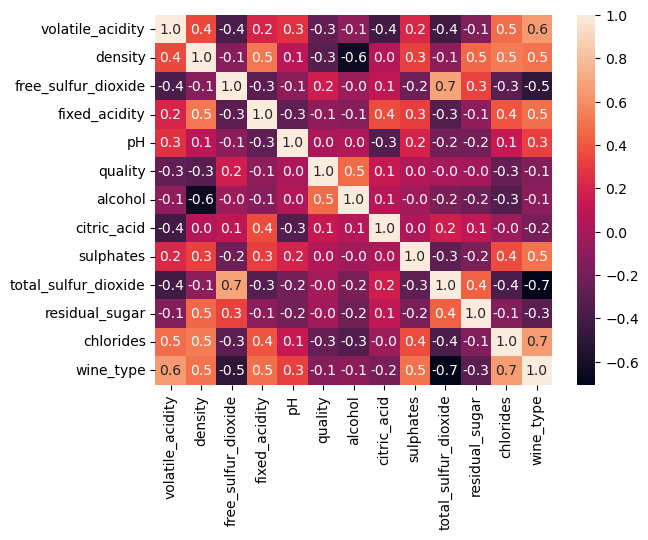

In [57]:
# Study correlations
sn.heatmap(data = valid_df.corr(), annot = True, fmt='.1f')
plt.show()

  Step 3. Split and Scale Data  
  
We wiltrain three different models: 1) ridge regression (in case that the regression is linear), 2) polynomial regression (in case that the regression is non linear), and 3) Principal Component Regression (in case that dimensionality reduction improves performance).  
  
Ridge regression benefits from the features being in the same scale, and since some outliers are still present due to the value of their information, a robust scaler will be applied.

In [58]:
y = valid_df.quality
X = valid_df.drop(columns=['quality'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def transform_data(X_train, X_test):
    'Since there are many outliers in the data, I chose to use a robust scaler'
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = transform_data(X_train, X_test)
X_train_scaled

array([[-0.78947368, -0.30769231, -0.2       , ..., -0.30434783,
         0.03225806,  0.        ],
       [ 0.52631579, -0.13186813,  0.675     , ...,  0.41304348,
         0.        ,  0.        ],
       [ 0.10526316,  0.58241758, -0.8       , ..., -0.23913043,
         0.29032258,  1.        ],
       ...,
       [-0.21052632, -0.32967033, -0.15      , ...,  0.76086957,
        -0.80645161,  0.        ],
       [ 1.73684211,  0.40879121, -0.4       , ..., -0.10869565,
         1.16129032,  1.        ],
       [ 2.15789474,  0.10989011, -0.5       , ...,  0.80434783,
        -0.16129032,  0.        ]], shape=(3654, 12))

Step 4. Train Models  
Results are converted to integers since the trained models return float values.

In [59]:
def get_mse(model, X80, X20, y80, y20):
    
    y20_predicted = model.predict(X20)
    y80_predicted = model.predict(X80)

    train_mse = round(mse(y80, y80_predicted), 2)
    test_mse = round(mse(y20, y20_predicted), 2)

    return (f'train mse = {train_mse}, test mse = {test_mse}')

def get_mae(model, X80, X20, y80, y20):
    
    y20_predicted = model.predict(X20)
    y80_predicted = model.predict(X80)

    train_mse = round(mae(y80, y80_predicted), 2)
    test_mse = round(mae(y20, y20_predicted), 2)

    return (f'train mae = {train_mse}, test mae = {test_mse}')

In [60]:
def train_rr(X80, X20, y80, y20):
    rgs = Ridge()

    # Find best parameters for the model
    grid_values = {'alpha': [0.1, 0.5, 1, 10]}
    grid_clf = GridSearchCV(rgs, param_grid = grid_values, scoring='neg_mean_squared_error')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    return (get_mse(best_model, X80, X20, y80, y20) + '\n' + get_mae(best_model, X80, X20, y80, y20))

def train_pr(X80, X20, y80, y20):
    poly = PolynomialFeatures(degree=2) # Already overfits in degree 2, higher degrees overfit even more
    pX80 = poly.fit_transform(X80)
    pX20 = poly.transform(X20)
    
    rgs = LinearRegression().fit(pX80, y80)

    return (get_mse(rgs, pX80, pX20, y80, y20) + '\n' + get_mae(rgs, pX80, pX20, y80, y20))

def train_pcr(X80, X20, y80, y20):
    
    pcr_pipeline = Pipeline([
    ('pca', PCA(n_components=5)),  
    ('regressor', LinearRegression())
    ])
    
    pcr_pipeline.fit(X80, y80)

    return (get_mse(pcr_pipeline, X80, X20, y80, y20) + '\n' + get_mae(pcr_pipeline, X80, X20, y80, y20))

def train_dr(X80, X20, y80, y20):

    DR = DummyRegressor(strategy='mean').fit(X80, y80)
    y20_predicted = DR.predict(X20)

    return (f'test mes = {mse(y20, y20_predicted):.2f}, test mae = {mae(y20, y20_predicted)}')

def train_ppcr(X80, X20, y80, y20):
    
    pipeline = Pipeline([
    ('pca', PCA(n_components=5)),  # Step 1: Apply PCA
    ('poly', PolynomialFeatures(degree=2)),  # Step 2: Generate polynomial features
    ('model', Ridge())  # Step 3: Fit a linear regression model
    ])
    
    pipeline.fit(X80, y80)

    return (get_mse(pipeline, X80, X20, y80, y20) + '\n' + get_mae(pipeline, X80, X20, y80, y20))

def train_models(X80, X20, y80, y20):
    results = dict()
    results['Ridge Regression'] = train_rr(X80, X20, y80, y20)
    results['Polynomial Regression'] = train_pr(X80, X20, y80, y20)
    results['Principal Component Regression'] = train_pcr(X80, X20, y80, y20)
    results['Polynomial + Principal Component Ridge Regression'] = train_ppcr(X80, X20, y80, y20)
    results['Dummy Regressor (baseline)'] = train_dr(X80, X20, y80, y20)
    return results

model_scores = train_models(X_train_scaled, X_test_scaled, y_train, y_test)
for key, value in model_scores.items():
    print(key,':', value)


Ridge Regression : train mse = 0.53, test mse = 0.55
train mae = 0.57, test mae = 0.57
Polynomial Regression : train mse = 0.48, test mse = 0.62
train mae = 0.53, test mae = 0.56
Principal Component Regression : train mse = 0.61, test mse = 0.62
train mae = 0.6, test mae = 0.62
Polynomial + Principal Component Ridge Regression : train mse = 0.57, test mse = 0.64
train mae = 0.58, test mae = 0.61
Dummy Regressor (baseline) : test mes = 0.79, test mae = 0.6970119972836339


Since lower MSE and MAE values indicate better predictive performance, all evaluated models successfully outperformed the baseline dummy regressor. Polynomial regression was unable to improve performance beyond degree 2 without significant overfitting, suggesting that the relationship between the features and wine quality is largely linear, with only limited nonlinear patterns present in the dataset.

As an additional experiment, separate models were trained for red and white wine in an attempt to improve prediction accuracy. However, the performance improvements were negligible, indicating that combining both wine types did not significantly reduce the model’s ability to generalize.

Performance could likely be improved further by:
- Collecting a larger and more diverse dataset
- Adding new features
- Training more advanced models capable of learning more complex relationships, such as neural networks